<a href="https://colab.research.google.com/github/Pooya-Moayed/Bachelors-Desertation/blob/Regression/Pooya_Project_Regression_Zone_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Loading Data**


In [ ]:
import pandas as pd

data = pd.read_excel('/content/drive/MyDrive/Project/Regression - Zone1.xlsx',index_col=None)

data.head()

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam,A1
0,191,241,238,236,249,8.2,8514,1321,45,39
1,194,240,235,234,251,8.2,7184,1158,45,37
2,194,241,233,234,249,8.2,8546,1350,50,37
3,194,242,242,234,250,8.7,8337,1427,50,37
4,195,239,239,237,250,8.3,8262,1409,45,36


In [ ]:
len(data)

269

# **2. Preparing Data**

In [ ]:
# Split into X and y

X = data.drop('A1', axis=1)
y = data['A1']

In [ ]:
X

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
0,191,241,238,236,249,8.2,8514,1321,45
1,194,240,235,234,251,8.2,7184,1158,45
2,194,241,233,234,249,8.2,8546,1350,50
3,194,242,242,234,250,8.7,8337,1427,50
4,195,239,239,237,250,8.3,8262,1409,45
...,...,...,...,...,...,...,...,...,...
264,195,233,236,237,251,7.9,8276,1388,50
265,183,233,230,232,252,7.9,7986,1331,45
266,183,233,237,233,251,7.9,7969,1384,45
267,188,231,241,237,250,9.3,8065,1288,40


In [ ]:
y

0      39
1      37
2      37
3      37
4      36
       ..
264    35
265    46
266    46
267    41
268    39
Name: A1, Length: 269, dtype: int64

In [ ]:
# Split data into training and test data

from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
115,194,239,239,238,252,7.50,8300,1435,40
33,192,242,238,241,250,8.10,8544,1471,40
180,191,239,241,238,250,7.70,8085,1270,45
141,190,236,235,235,251,7.40,8495,1445,40
248,187,235,238,238,249,7.90,8257,1350,45
...,...,...,...,...,...,...,...,...,...
20,196,241,238,235,249,8.40,8591,1299,50
188,191,239,234,237,249,7.75,8067,1325,35
71,194,238,236,236,249,7.90,8232,1312,35
106,186,237,238,239,250,7.50,8290,1335,40


In [ ]:
X_test

,T1,T2,T3,T4,Td,Pd,Charge,KWmm,Tam
30,194,238,240,237,250,8.10,8374,1459,50
116,194,238,236,234,251,7.50,8460,1470,35
79,186,242,239,234,250,8.50,8481,1310,40
127,189,239,238,233,249,7.50,8377,1419,45
190,191,240,237,235,248,7.50,8322,1403,45
137,191,240,242,241,251,7.50,8258,1318,50
202,191,241,233,235,251,7.75,8271,1430,45
45,191,241,238,235,249,8.20,8314,1470,45
173,192,232,237,236,251,7.70,8251,1290,50
239,191,239,235,235,251,8.50,8135,1440,45


In [ ]:
y_train

115    36
33     38
180    38
141    42
248    43
       ..
20     34
188    38
71     35
106    44
102    37
Name: A1, Length: 215, dtype: int64

In [ ]:
y_test

30     38
116    37
79     43
127    41
190    39
137    39
202    39
45     41
173    38
239    38
179    36
267    41
220    41
82     45
186    38
185    38
241    41
265    46
104    41
60     38
261    39
184    38
46     40
42     35
181    37
9      41
22     35
193    36
109    39
24     39
113    37
68     33
143    40
217    44
197    41
6      40
120    39
67     36
119    40
118    40
25     41
125    40
165    35
19     34
77     40
209    41
90     40
170    35
93     39
258    39
15     39
150    42
224    42
242    41
Name: A1, dtype: int64

In [ ]:
y_test.value_counts()

41    11
39    10
40     8
38     7
35     4
37     3
36     3
42     2
43     1
45     1
46     1
33     1
44     1
34     1
Name: A1, dtype: int64

In [ ]:
y_train.value_counts()

39    55
40    39
41    22
38    19
42    19
36    13
37    12
34     6
35     6
43     6
45     4
48     3
49     3
46     3
44     2
50     2
47     1
Name: A1, dtype: int64

##Pearson Correlation  (detecting correlated data)

<function matplotlib.pyplot.show(*args, **kw)>

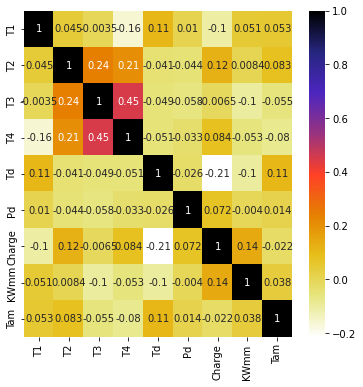

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Using Pearson Correlation
plt.figure(figsize=(6,6))
cor = X.corr(method='pearson')
#cor2 = X.corr(method='spearman')
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#sns.heatmap(cor2, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

# **3. Building Machine Learning Model**

## All Models

In [ ]:
!pip install catboost
!pip install logitboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 106 kB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# 3.1. Ridge Model

In [ ]:
from sklearn.linear_model import Ridge
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
model = Ridge()
model.fit(X_train, y_train)

Ridge()

In [ ]:
#Evaluate our model
model.score(X_test, y_test)

0.8333361246188006

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([ 0.06703744,  0.8806154 ,  0.83632137, -0.57973259,  0.83282876])

In [ ]:
#Use the trained model to make predictions

y_preds = model.predict(X_test)
#y_preds[:10]
y_preds

array([37.19389241, 37.34859127, 43.26634957, 40.76682339, 39.24931078,
       39.22413856, 39.03379699, 39.23467366, 38.22406421, 38.72375145,
       37.37675513, 40.84699319, 40.42812076, 41.43794386, 38.71460496,
       38.28718992, 40.46141284, 43.9798543 , 40.49488422, 38.0402326 ,
       39.21262939, 38.95218799, 38.99247369, 36.39944685, 37.68529543,
       39.98239562, 36.69750042, 37.01915102, 39.10747093, 37.97837569,
       37.18430846, 35.90849626, 39.88925281, 42.87364637, 40.53215539,
       40.36238473, 39.0038629 , 36.35146291, 39.73318133, 40.04753162,
       40.30880869, 39.89683957, 36.35880816, 35.3749097 , 39.5157762 ,
       40.23230424, 39.80351927, 37.14021254, 38.58914721, 38.8105703 ,
       37.58810535, 40.30345042, 41.45381408, 40.46178041])

In [ ]:
#y_test[:10]
y_test

30     38
116    37
79     43
127    41
190    39
137    39
202    39
45     41
173    38
239    38
179    36
267    41
220    41
82     45
186    38
185    38
241    41
265    46
104    41
60     38
261    39
184    38
46     40
42     35
181    37
9      41
22     35
193    36
109    39
24     39
113    37
68     33
143    40
217    44
197    41
6      40
120    39
67     36
119    40
118    40
25     41
125    40
165    35
19     34
77     40
209    41
90     40
170    35
93     39
258    39
15     39
150    42
224    42
242    41
Name: A1, dtype: int64

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error, max_error
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 1.1280675268857108
mean_absolute_error= 0.7685972131011275
mean_absolute_percentage_error= 0.01988085529716783
median_absolute_error= 0.5384033726735211
max_error= 3.562056142724529


# 3.2. Random Forest Regression Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
rf = RandomForestRegressor(max_depth= 20,
 max_features= 'auto',
 min_samples_leaf= 1,
 min_samples_split= 8,
 n_estimators= 100)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=8)

In [ ]:
#Evaluate our model
rf.score(X_test, y_test)

0.9093815431327806

In [ ]:
# Cross-validation
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5)

array([0.70713566, 0.86191117, 0.89745755, 0.87042417, 0.90813919])

In [ ]:
y_preds = rf.predict(X_test)
y_preds

array([36.03077331, 36.4311294 , 42.78025549, 41.8552262 , 39.00601399,
       38.98283333, 39.05603419, 38.96028355, 38.38909513, 38.04616883,
       37.32690759, 41.14856576, 41.12806699, 44.92795667, 38.2182399 ,
       38.40403524, 40.37094364, 45.18347079, 41.56448195, 38.59152878,
       39.03767552, 38.69764935, 38.95165329, 35.11077911, 37.83357592,
       40.22039719, 35.34381102, 36.06505866, 39.00328571, 38.07824739,
       36.39297788, 34.91538284, 40.0025    , 43.0987183 , 41.30902704,
       41.06942222, 38.81118864, 35.96233308, 40.01125   , 40.25613131,
       40.51457698, 40.03735354, 35.22708844, 34.97610182, 39.60066645,
       40.90896259, 40.08583333, 37.47469006, 38.91354434, 38.90875303,
       37.87609241, 40.92286003, 42.1055393 , 41.14045883])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.613352703425346
mean_absolute_error= 0.5297844588539014
mean_absolute_percentage_error= 0.013811613809482485
median_absolute_error= 0.32641903358079816
max_error= 2.474690059940059


## 3.3. KNeighbours Regression Model

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
neigh = KNeighborsRegressor(n_neighbors = 50)
neigh.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=50)

In [ ]:
#Evaluate our model
neigh.score(X_test, y_test)

-0.04382599179206581

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(neigh, X, y, cv=5)

array([-0.18980726,  0.00418569,  0.0412186 ,  0.08670489, -0.2143776 ])

In [ ]:
y_preds = neigh.predict(X_test)
y_preds

array([40.02, 40.58, 40.34, 40.16, 39.22, 39.36, 38.8 , 39.56, 39.5 ,
       38.7 , 38.94, 38.84, 41.06, 38.98, 38.98, 39.46, 39.46, 38.98,
       38.82, 40.44, 39.92, 39.42, 38.82, 39.5 , 38.88, 40.12, 40.68,
       38.82, 38.86, 39.  , 40.44, 40.02, 39.08, 39.48, 38.82, 40.64,
       38.9 , 39.  , 39.14, 40.36, 40.74, 39.02, 38.9 , 38.82, 40.66,
       40.62, 39.56, 39.  , 38.92, 40.6 , 39.08, 40.82, 39.42, 39.14])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 7.065155555555556
mean_absolute_error= 1.9555555555555555
mean_absolute_percentage_error= 0.05100456968449637
median_absolute_error= 1.4499999999999993
max_error= 7.020000000000003


# 3.4. DecisionTree Regression Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
dt = DecisionTreeRegressor(random_state=1)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=1)

In [ ]:
#Evaluate our model
dt.score(X_test, y_test)

0.7838577291381669

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(dt, X, y, cv=5)

array([0.55590744, 0.63629518, 0.78353821, 0.71699154, 0.65837417])

In [ ]:
y_preds = dt.predict(X_test)
y_preds

array([36., 37., 42., 41., 39., 39., 39., 39., 39., 38., 38., 41., 41.,
       46., 38., 39., 40., 41., 41., 39., 39., 39., 41., 34., 38., 40.,
       36., 36., 39., 39., 37., 36., 40., 45., 41., 41., 39., 36., 40.,
       41., 40., 40., 36., 35., 40., 41., 40., 38., 38., 39., 37., 41.,
       42., 41.])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 1.462962962962963
mean_absolute_error= 0.7222222222222222
mean_absolute_percentage_error= 0.018644657922035644
median_absolute_error= 0.5
max_error= 5.0


# 3.5. XGBOOST Regressor

In [ ]:
from xgboost import XGBRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
xgb = XGBRegressor( max_depth=50, learning_rate=0.1, n_estimators=100)
xgb.fit(X_train,y_train)

[06:09:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


XGBRegressor(max_depth=50)

In [ ]:
#Evaluate our model
xgb.score(X_test, y_test)

0.9291303319201668

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(xgb, X, y, cv=5)

[06:09:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:09:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:09:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:09:08] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[06:09:08] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


array([0.6792787 , 0.8142355 , 0.91449481, 0.90920348, 0.87685588])

In [ ]:
y_preds = xgb.predict(X_test)
y_preds

array([36.72134 , 36.65135 , 43.068027, 41.112732, 38.98993 , 39.00267 ,
       39.05092 , 38.88156 , 37.970455, 38.361042, 36.780502, 40.15223 ,
       40.74274 , 44.257908, 38.12009 , 37.95533 , 40.03908 , 44.119793,
       40.84693 , 38.72423 , 39.328373, 38.786606, 39.0859  , 34.75406 ,
       37.357338, 40.361202, 35.592087, 35.940857, 38.797184, 37.861423,
       37.13344 , 34.179516, 39.998535, 43.674152, 40.924744, 40.588284,
       38.8463  , 35.243317, 39.92343 , 40.32529 , 40.662136, 40.07889 ,
       34.91247 , 34.91485 , 39.80012 , 41.239273, 39.940693, 36.81965 ,
       39.25065 , 39.382256, 38.24676 , 41.0247  , 41.94621 , 41.086933],
      dtype=float32)

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 0.47968266079961147
mean_absolute_error= 0.48168154116030093
mean_absolute_percentage_error= 0.012392036839576338
median_absolute_error= 0.32556915283203125
max_error= 2.118438720703125


#3.6. CATBOOST Regressor


In [ ]:
from catboost import CatBoostRegressor
import numpy as np

#Setup random seed
np.random.seed(42)

#Build our model and fit the data
catb = CatBoostRegressor(iterations=2, learning_rate=1, depth=2)
# Fit model
catb.fit(X_train, y_train)

0:	learn: 2.1827932	total: 46.4ms	remaining: 46.4ms
1:	learn: 1.5883662	total: 46.7ms	remaining: 0us


In [ ]:
#Evaluate our model
catb.score(X_test, y_test)

0.6863068613838736

In [ ]:
from sklearn.model_selection import cross_val_score
np.random.seed(42)
cross_val_score(catb, X, y, cv=5)

0:	learn: 2.0786226	total: 330us	remaining: 330us
1:	learn: 1.3354642	total: 3.33ms	remaining: 0us
0:	learn: 1.9189755	total: 275us	remaining: 275us
1:	learn: 1.4251906	total: 507us	remaining: 0us
0:	learn: 2.3257675	total: 256us	remaining: 256us
1:	learn: 1.5956087	total: 885us	remaining: 0us
0:	learn: 2.1438086	total: 232us	remaining: 232us
1:	learn: 1.5302923	total: 848us	remaining: 0us
0:	learn: 2.0740588	total: 223us	remaining: 223us
1:	learn: 1.5930947	total: 1.08ms	remaining: 0us


array([0.57409892, 0.79173941, 0.38705715, 0.58599814, 0.63125039])

In [ ]:
y_preds = catb.predict(X_test)
y_preds

array([37.31137701, 37.32771407, 40.21170301, 40.22804008, 40.22804008,
       40.22804008, 40.22804008, 40.21170301, 37.32771407, 40.21170301,
       37.32771407, 40.21170301, 40.22804008, 46.12303141, 40.22804008,
       37.32771407, 40.21170301, 45.85469519, 40.22804008, 37.31137701,
       40.21170301, 40.22804008, 40.21170301, 37.32771407, 37.32771407,
       40.21170301, 37.31137701, 37.32771407, 40.22804008, 37.31137701,
       37.32771407, 36.21008437, 40.22804008, 40.22804008, 40.22804008,
       40.21170301, 40.22804008, 37.32771407, 40.22804008, 40.22804008,
       40.21170301, 40.22804008, 37.32771407, 36.19374731, 40.21170301,
       40.22804008, 40.22804008, 37.32771407, 40.22804008, 37.32771407,
       37.31137701, 40.22804008, 40.22804008, 40.22804008])

In [ ]:
print('mean_squared_error=',mean_squared_error(y_test, y_preds))
print('mean_absolute_error=',mean_absolute_error(y_test, y_preds))
print('mean_absolute_percentage_error=',mean_absolute_percentage_error(y_test, y_preds))
print('median_absolute_error=',median_absolute_error(y_test, y_preds))
print('max_error=',max_error(y_test, y_preds))

mean_squared_error= 2.1232378178554474
mean_absolute_error= 1.192681085601888
mean_absolute_percentage_error= 0.031068306167318642
median_absolute_error= 0.9556641985125971
max_error= 3.7719599200711826


##Results

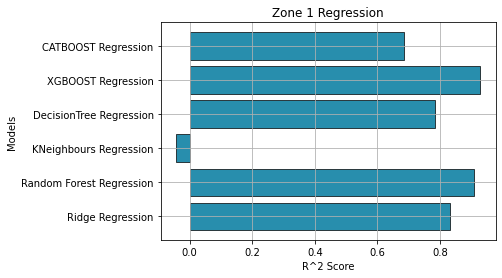

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x_valeues=['Ridge Regression', 'Random Forest Regression',
           'KNeighbours Regression', 'DecisionTree Regression', 'XGBOOST Regression', 'CATBOOST Regression']

y_valeues=[model.score(X_test, y_test), rf.score(X_test, y_test), neigh.score(X_test, y_test), dt.score(X_test, y_test),
           xgb.score(X_test, y_test), catb.score(X_test, y_test)]

width=1

# plot
plt.barh(x_valeues, y_valeues, color='#288ead', edgecolor="black", linewidth=0.7)

plt.xlabel('R^2 Score')
plt.ylabel('Models')
plt.title('Zone 1 Regression')
plt.grid(True)

plt.show()